# Project Name - Car Price Prediction with Machine Learning

# Project Summary -

# 1. Know The Data

## Import Libraries

In [1]:
# Import Libraries
# Importing Numpy & Pandas for data processing & data wrangling

import numpy as np
import pandas as pd

# Importing  tools for visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Import preprocessing libraries
from sklearn.preprocessing import MinMaxScaler,StandardScaler


# Import Model
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor




# Import evaluation metric libraries
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

# Import model selection libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score


# Import tree for visualization
from sklearn.tree import export_graphviz
from sklearn import tree
from IPython.display import SVG,display
from graphviz import Source


import pickle

# Library used for ignore warnings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline 




## Dataset Loading

In [2]:
df=pd.read_csv("car data.csv")

## Dataset First View

In [3]:

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Dataset Rows & Columns count

In [4]:
# Checking number of rows and columns of the dataset using shape
print("Number of rows are: ",df.shape[0])
print("Number of columns are: ",df.shape[1])

Number of rows are:  301
Number of columns are:  9


## Dataset Information

In [5]:
# Checking information about the dataset using info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


## Duplicate Values

In [6]:
# Dataset Duplicate Value Count
dup = df.duplicated().sum()
print(f'number of duplicated rows are {dup}')

number of duplicated rows are 2


## Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

# 2. Understanding The Variables

In [8]:
# Dataset Columns
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [9]:
#numerical stats
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Check Unique Values for each variable

In [10]:
# Check Unique Values for each variable.
for i in df.columns.tolist():
  print("No. of unique values in",i,"is",df[i].nunique())

No. of unique values in Car_Name is 98
No. of unique values in Year is 16
No. of unique values in Selling_Price is 156
No. of unique values in Present_Price is 147
No. of unique values in Kms_Driven is 206
No. of unique values in Fuel_Type is 3
No. of unique values in Seller_Type is 2
No. of unique values in Transmission is 2
No. of unique values in Owner is 3


# 3. Data Preprocessing

In [11]:
current_year = 2025

# Calculating the age of the vehicles by subtracting the 'Year' column from the 'Current Year'
df['age'] = current_year - df['Year']

In [12]:
# Renaming the columns for better understanding
df.rename(columns = {'Selling_Price':'Selling_Price(lacs)','Present_Price':'Present_Price(lacs)','Owner':'Past_Owners'},inplace = True)

In [13]:
# New updated DataFrame
df.head()

,Car_Name,Year,Selling_Price(lacs),Present_Price(lacs),Kms_Driven,Fuel_Type,Seller_Type,Transmission,Past_Owners,age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


In [14]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price(lacs)', 'Present_Price(lacs)',
       'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Past_Owners',
       'age'],
      dtype='object')

In [15]:
# Defining dependent variable
dependent_variable = ['Selling_Price(lacs)']

# 4. (EDA) Exploratory Data Analysis

## Data Visualization

### Chart - 1 : Top 10 Most Selling Car

In [16]:
# Chart - 1 Count plot visualization code for top 10 most selling car
# Count the occurrences of each unique car name in the 'Car_Name' column and take the top 10 most selling car
top10 = df['Car_Name'].value_counts()[:10]

print(top10)

Car_Name
city                         26
corolla altis                16
verna                        14
fortuner                     11
brio                         10
ciaz                          9
i20                           9
innova                        9
grand i10                     8
Royal Enfield Classic 350     7
Name: count, dtype: int64


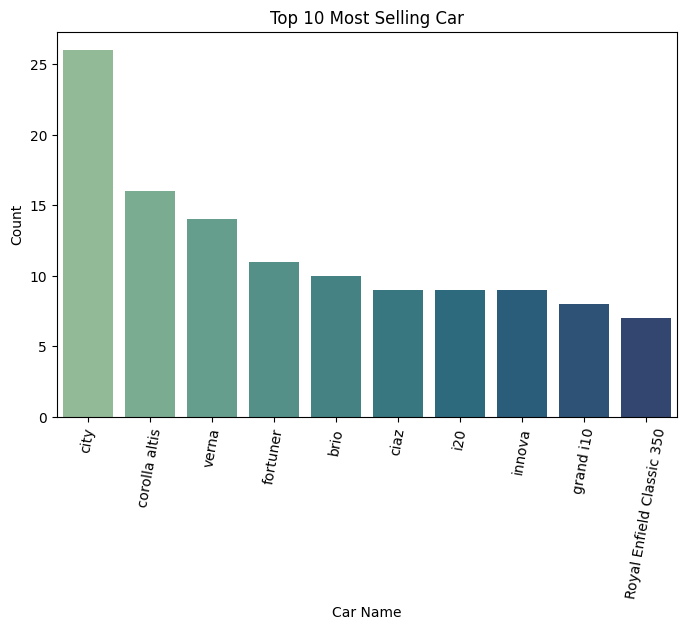

In [17]:
# Create a count plot to visualize the top 10 car

plt.figure(figsize=(8, 5))
sns.countplot(x='Car_Name', data=df, order=top10.index, palette='crest')

# Set labels and title for the plot
plt.xlabel('Car Name')
plt.ylabel('Count')
plt.title('Top 10 Most Selling Car')
plt.xticks(rotation=80)


# Display the plot
plt.show()

### Chart - 2 : Number of Cars Bought Each Year

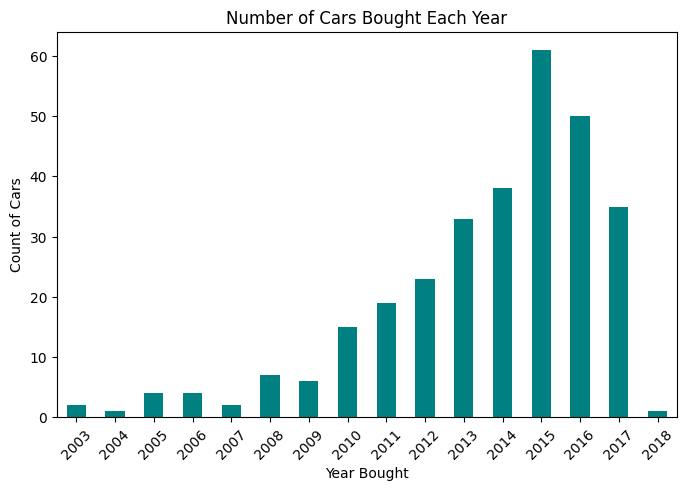

In [18]:
# Chart - 2 Bar plot visualization code for Number of Cars Bought Each Year
# Set the figure size for the plot
plt.figure(figsize=(8, 5))

# Group the data by the 'Year' column and count the number of occurrences for each year
yearly_counts = df.groupby('Year').count()['Car_Name']

# Create a bar plot to visualize the count of cars bought in each year
yearly_counts.plot(kind='bar',color='teal')

# Rotate the x-axis labels by 45 degrees for better readability
plt.xticks(rotation=45)

# Set labels and title for the plot
plt.xlabel('Year Bought')
plt.ylabel('Count of Cars')
plt.title('Number of Cars Bought Each Year')

# Display the plot
plt.show()

### Chart - 3 : Distribution of Categorical Variable

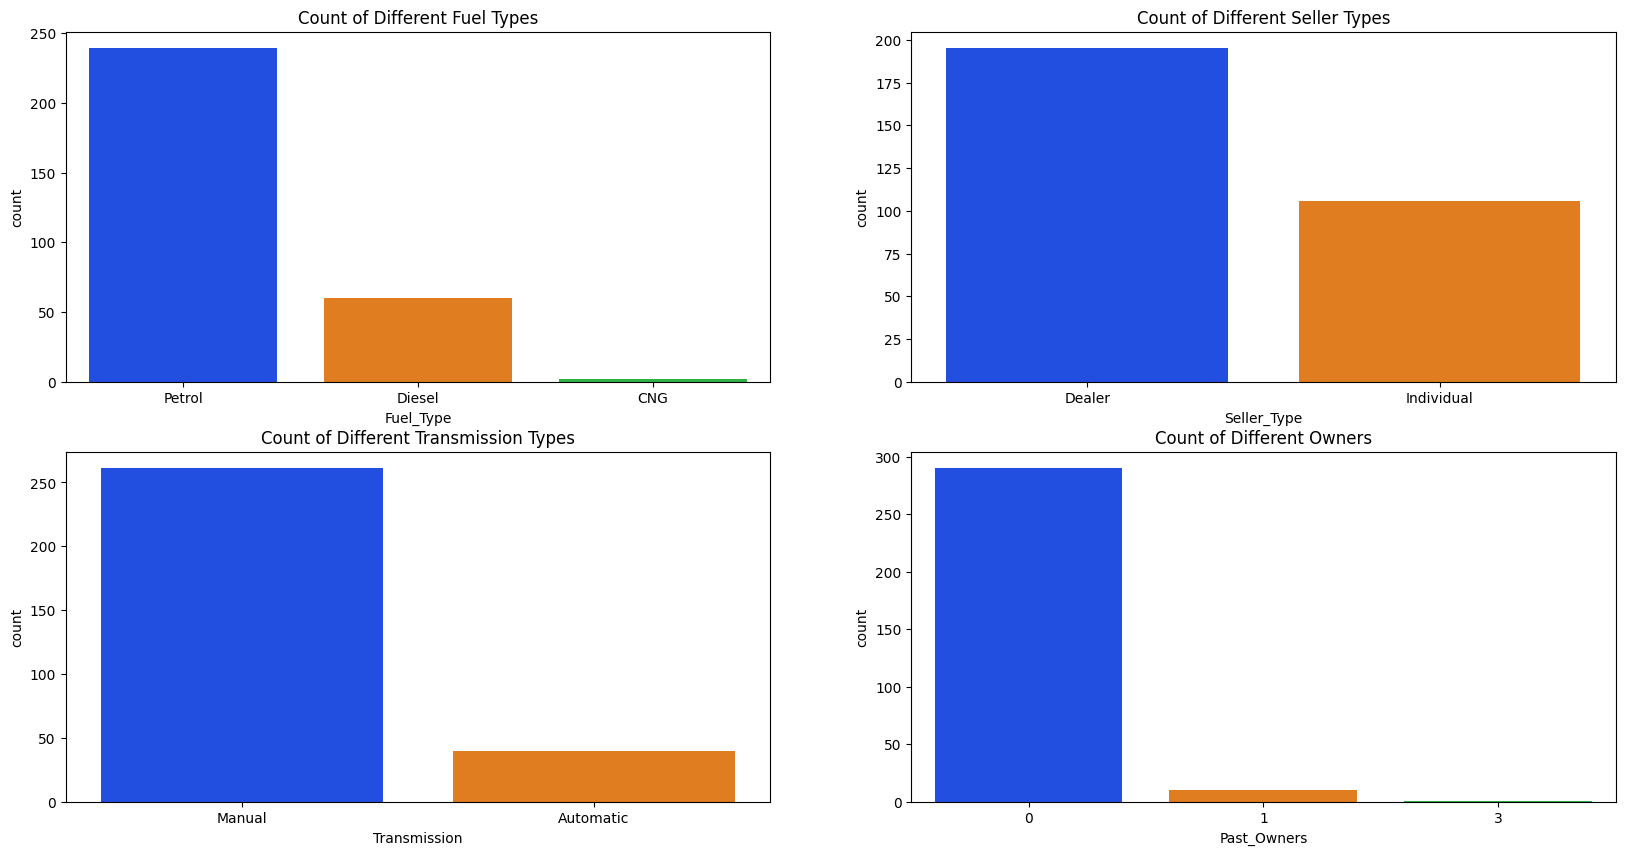

In [19]:
# Chart - 3 Count plot visualization code for Categorical Variable
# Create a 2x2 subplot
plt.figure(figsize=(20,10))

# Subplot 1: Count of different Fuel Types
plt.subplot(2,2,1)
sns.countplot(data=df, x = 'Fuel_Type',palette='bright')
plt.title("Count of Different Fuel Types")

# Subplot 2: Count of different Seller Types
plt.subplot(2,2,2)
sns.countplot(data=df, x = 'Seller_Type',palette='bright')
plt.title("Count of Different Seller Types")

# Subplot 3: Count of different Transmission Types
plt.subplot(2,2,3)
sns.countplot(data=df, x = 'Transmission',palette='bright')
plt.title("Count of Different Transmission Types")

# Subplot 4: Count of different Owners
plt.subplot(2,2,4)
sns.countplot(data=df, x ='Past_Owners',palette='bright')
plt.title("Count of Different Owners")

plt.show()

# Index(['Car_Name', 'Year', 'Selling_Price(lacs)', 'Present_Price(lacs)',
#        'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Past_Owners',
#        'age'],
#       dtype='object')

### Chart - 4 : Categorical Variable vs Target Variable¶

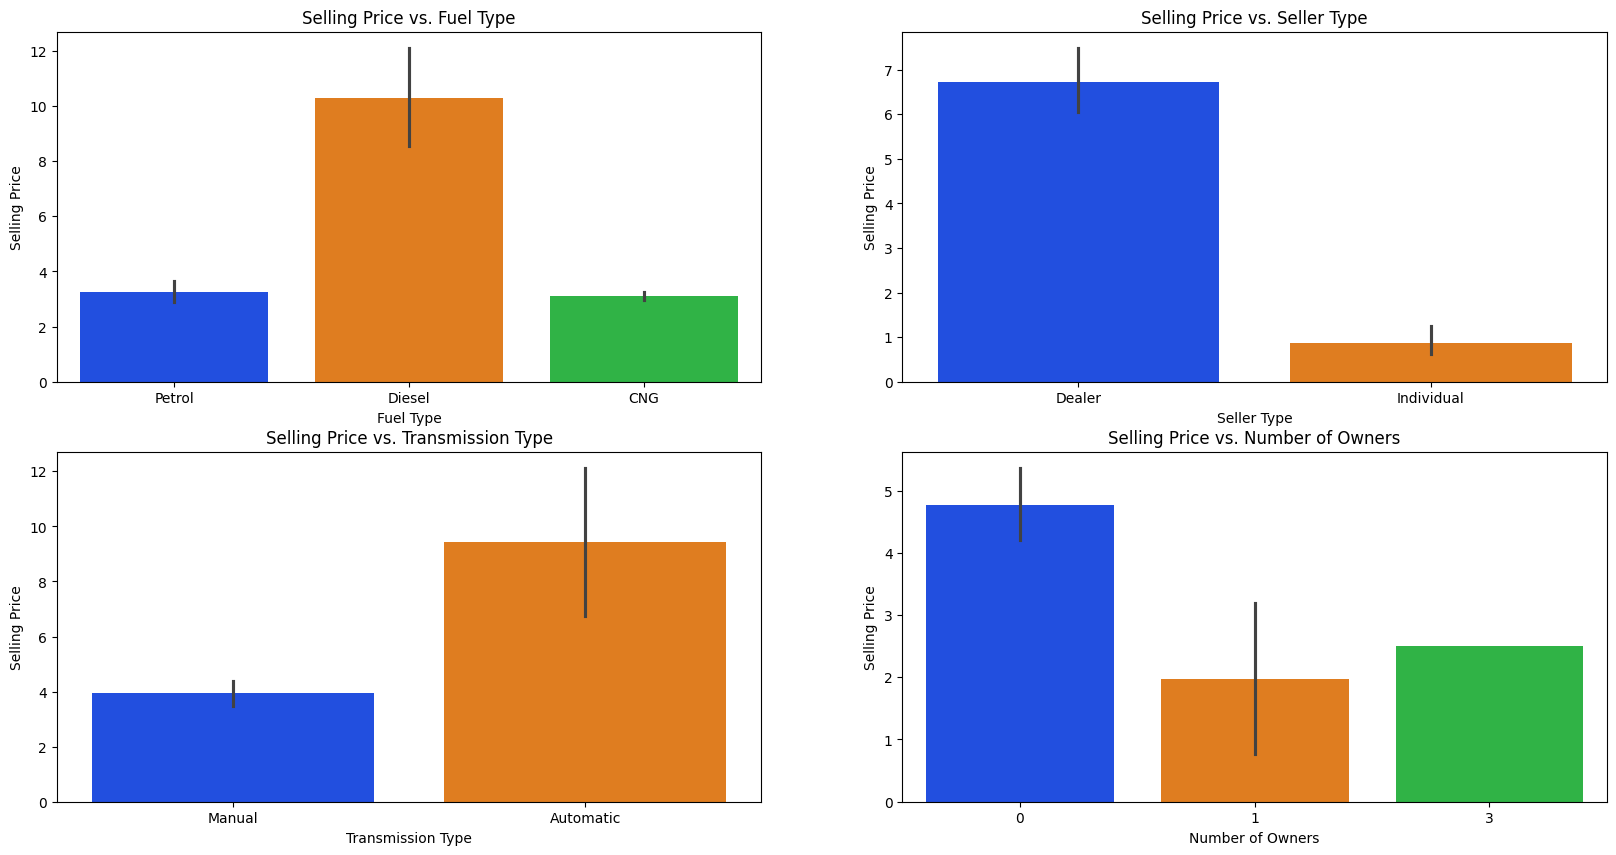

In [20]:
# Chart - 4 Barplot visualization code for categorical variable vs target variable
# Create a 2x2 subplot
plt.figure(figsize=(20,10))

# Subplot 1: Barplot for Selling_Price vs. Fuel_Type
plt.subplot(2,2,1)
sns.barplot(data=df, x='Fuel_Type', y='Selling_Price(lacs)',palette='bright')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.title('Selling Price vs. Fuel Type')

# Subplot 2: Barplot for Selling_Price vs. Seller_Type
plt.subplot(2,2,2)
sns.barplot(data=df, x='Seller_Type', y='Selling_Price(lacs)',palette='bright')
plt.xlabel('Seller Type')
plt.ylabel('Selling Price')
plt.title('Selling Price vs. Seller Type')

# Subplot 3: Barplot for Selling_Price vs. Transmission
plt.subplot(2,2,3)
sns.barplot(data=df, x='Transmission', y='Selling_Price(lacs)',palette='bright')
plt.xlabel('Transmission Type')
plt.ylabel('Selling Price')
plt.title('Selling Price vs. Transmission Type')

# Subplot 4: Barplot for Selling_Price vs. Owner
plt.subplot(2,2,4)
sns.barplot(data=df, x='Past_Owners', y='Selling_Price(lacs)',palette='bright')
plt.xlabel('Number of Owners')
plt.ylabel('Selling Price')
plt.title('Selling Price vs. Number of Owners')

# Display the plot
plt.show()

### Chart - 5 : Driven Kilometers vs Selling Price

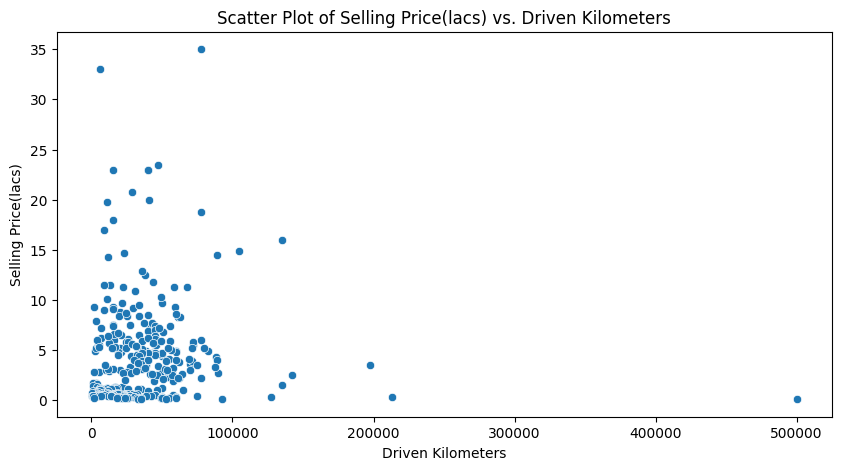

In [21]:
# Chart - 5 Scatter plot visualization code for Driven Kilometers vs Selling Price
# Set the figure size for the plot
plt.figure(figsize=(10,5))

# Create a scatter plot to visualize the relationship between Driven_kms and Selling_Price
sns.scatterplot(data=df, x='Kms_Driven', y='Selling_Price(lacs)')

# Set labels for the x and y axes
plt.xlabel('Driven Kilometers')
plt.ylabel('Selling Price(lacs)')

# Add a title to the plot
plt.title('Scatter Plot of Selling Price(lacs) vs. Driven Kilometers')

# Display the plot
plt.show()

### Chart-6: Numerical Variable – Outlier Detection using Boxplot

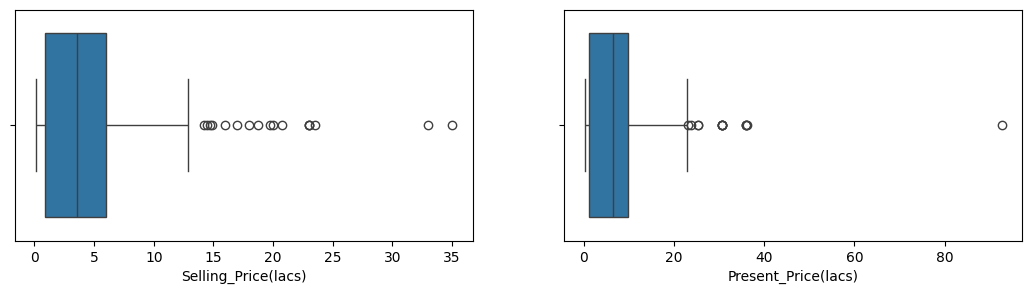

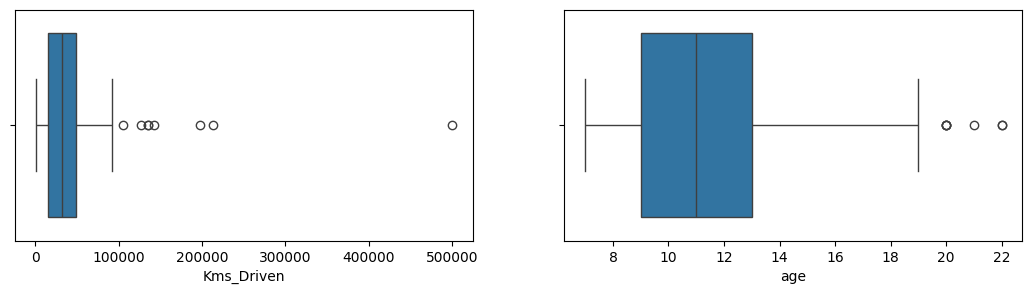

In [22]:
num_cols = ['Selling_Price(lacs)','Present_Price(lacs)','Kms_Driven','age']
i=0
while i < 4:
    fig = plt.figure(figsize=[13,3])
    #ax1 = fig.add_subplot(121)
    #ax2 = fig.add_subplot(122)
    
    #ax1.title.set_text(num_cols[i])
    plt.subplot(1,2,1)
    sns.boxplot(x=num_cols[i], data=df)
    i += 1
    
    #ax2.title.set_text(num_cols[i])
    plt.subplot(1,2,2)
    sns.boxplot(x=num_cols[i], data=df)
    i += 1
    # plt.xlabel(num_cols[i])
    
    plt.show()

In [23]:
df[df['Present_Price(lacs)'] > df['Present_Price(lacs)'].quantile(0.99)]

,Car_Name,Year,Selling_Price(lacs),Present_Price(lacs),Kms_Driven,Fuel_Type,Seller_Type,Transmission,Past_Owners,age
64,fortuner,2017,33.0,36.23,6000,Diesel,Dealer,Automatic,0,8
86,land cruiser,2010,35.0,92.60,78000,Diesel,Dealer,Manual,0,15


In [24]:
df[df['Selling_Price(lacs)'] > df['Selling_Price(lacs)'].quantile(0.99)]

,Car_Name,Year,Selling_Price(lacs),Present_Price(lacs),Kms_Driven,Fuel_Type,Seller_Type,Transmission,Past_Owners,age
63,fortuner,2015,23.5,35.96,47000,Diesel,Dealer,Automatic,0,10
64,fortuner,2017,33.0,36.23,6000,Diesel,Dealer,Automatic,0,8
86,land cruiser,2010,35.0,92.60,78000,Diesel,Dealer,Manual,0,15


In [25]:
df[df['Kms_Driven'] > df['Kms_Driven'].quantile(0.99)]

,Car_Name,Year,Selling_Price(lacs),Present_Price(lacs),Kms_Driven,Fuel_Type,Seller_Type,Transmission,Past_Owners,age
84,innova,2005,3.49,13.46,197176,Diesel,Dealer,Manual,0,20
179,Honda Karizma,2010,0.31,1.05,213000,Petrol,Individual,Manual,0,15
196,Activa 3g,2008,0.17,0.52,500000,Petrol,Individual,Automatic,0,17


### Chart - 7 - Correlation Heatmap

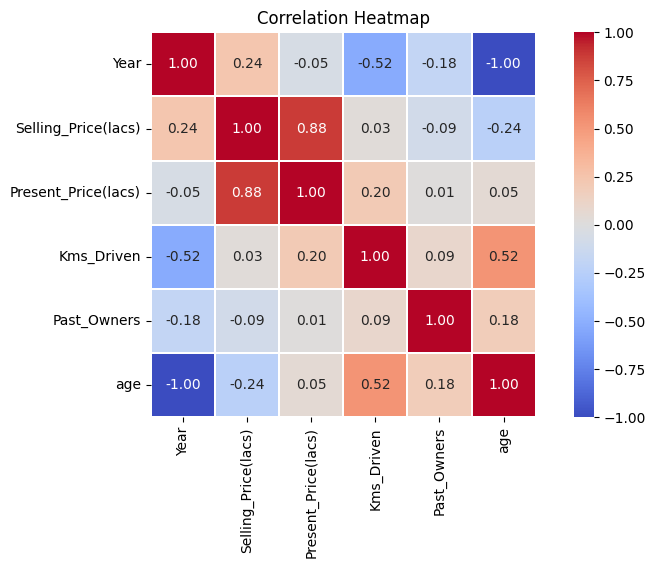

In [26]:
# Correlation Heatmap visualization code
# Set the size of the plot

# Drop non-numeric columns (e.g., 'category_column')
df_numeric = df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 5))

# Create a heatmap of the correlation matrix with annotations
sns.heatmap(df_numeric.corr(), annot=True, linewidths=0.1, fmt='.2f', square=True, cmap='coolwarm')

# Add a title to the plot
plt.title("Correlation Heatmap")

# Display the plot
plt.show()

 # 5. Feature Engineering

### HandlingOutliers

In [27]:
# Handling Outliers & Outlier treatments
# Removing outliers by Using IQR method:

q1, q3, median = df['Selling_Price(lacs)'].quantile([0.25,0.75,0.5])
lower_limit = q1 - 1.5*(q3-q1)
upper_limit = q3 + 1.5*(q3-q1)
df['Selling_Price(lacs)'] = np.where(
    df['Selling_Price(lacs)'] > upper_limit, 
    median,
    np.where(df['Selling_Price(lacs)'] < lower_limit,
             median,
             df['Selling_Price(lacs)']
            )
)
# Removing outliers by Capping:
for col in ['Present_Price(lacs)','Kms_Driven','Past_Owners','age']:
  upper_limit = df[col].quantile(0.99)
  df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])
  # print(col,upper_limit

### scatter plot after handling outliers

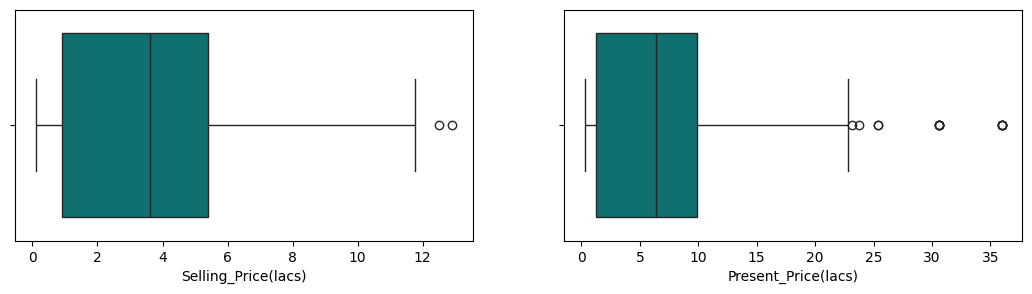

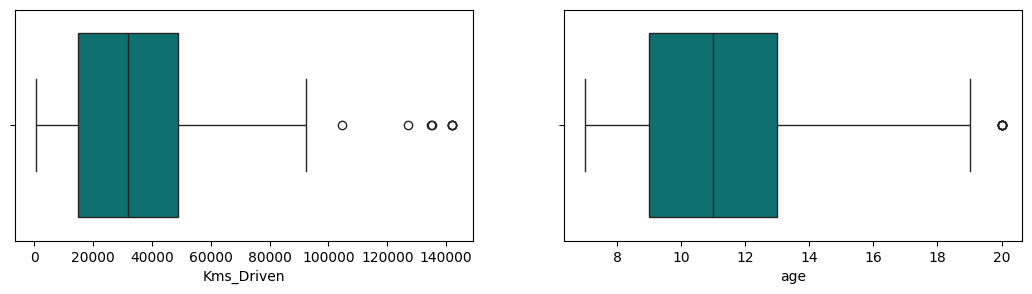

In [28]:
i=0
while i < 4:
    fig = plt.figure(figsize=[13,3])
    #ax1 = fig.add_subplot(121)
    #ax2 = fig.add_subplot(122)
    
    #ax1.title.set_text(num_cols[i])
    plt.subplot(1,2,1)
    sns.boxplot(x=num_cols[i], data=df,color='teal')
    i += 1
    
    #ax2.title.set_text(num_cols[i])
    plt.subplot(1,2,2)
    sns.boxplot(x=num_cols[i], data=df,color='teal')
    i += 1
    # plt.xlabel(num_cols[i])
    
    plt.show()

### 2. Categorical Encoding

In [29]:
# Before Categorical Encoding, Remove the 'Car Name' as it's no longer needed
df.drop(['Car_Name'], axis=1, inplace=True)

# Removing 'Year' column as we've already calculated the age in the 'no_year' column
df.drop(['Year'], axis=1, inplace=True)

In [30]:
# Using one-hot encoding to convert categorical variables into numerical format
df = pd.get_dummies(df,drop_first=True)

In [31]:
df.head()


,Selling_Price(lacs),Present_Price(lacs),Kms_Driven,Past_Owners,age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000.0,0.0,11.0,False,True,False,True
1,4.75,9.54,43000.0,0.0,12.0,True,False,False,True
2,7.25,9.85,6900.0,0.0,8.0,False,True,False,True
3,2.85,4.15,5200.0,0.0,14.0,False,True,False,True
4,4.60,6.87,42450.0,0.0,11.0,True,False,False,True


### 3. Feature Selection

In [32]:
# Select your features wisely to avoid overfitting
features = [i for i in df.columns if i not in ['Selling_Price(lacs)']]
features

['Present_Price(lacs)',
 'Kms_Driven',
 'Past_Owners',
 'age',
 'Fuel_Type_Diesel',
 'Fuel_Type_Petrol',
 'Seller_Type_Individual',
 'Transmission_Manual']

In [33]:
# Remove multicollinearity by using VIF technique
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [34]:
continuous_variables = ['Present_Price(lacs)', 'Kms_Driven', 'Past_Owners', 'age']
continuous_feature_df = pd.DataFrame(df[continuous_variables])
continuous_feature_df

,Present_Price(lacs),Kms_Driven,Past_Owners,age
0,5.59,27000.0,0.0,11.0
1,9.54,43000.0,0.0,12.0
2,9.85,6900.0,0.0,8.0
3,4.15,5200.0,0.0,14.0
4,6.87,42450.0,0.0,11.0
...,...,...,...,...
296,11.60,33988.0,0.0,9.0
297,5.90,60000.0,0.0,10.0
298,11.00,87934.0,0.0,16.0
299,12.50,9000.0,0.0,8.0


In [35]:
calc_vif(df[[i for i in continuous_feature_df]])

,variables,VIF
0,Present_Price(lacs),2.186873
1,Kms_Driven,4.509332
2,Past_Owners,1.059126
3,age,4.329023


In [36]:
# This is the final data for modeling
df.head()

,Selling_Price(lacs),Present_Price(lacs),Kms_Driven,Past_Owners,age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000.0,0.0,11.0,False,True,False,True
1,4.75,9.54,43000.0,0.0,12.0,True,False,False,True
2,7.25,9.85,6900.0,0.0,8.0,False,True,False,True
3,2.85,4.15,5200.0,0.0,14.0,False,True,False,True
4,4.60,6.87,42450.0,0.0,11.0,True,False,False,True


### 4.Data Transformation

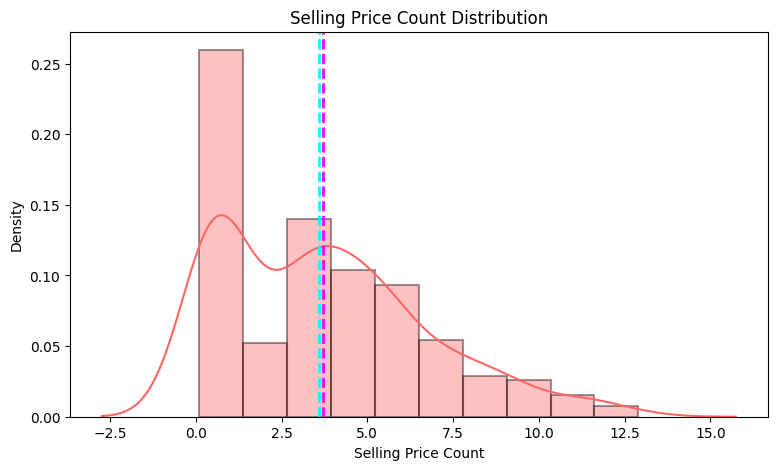

In [37]:
# Transform the data
# Visualizing the distribution of the dependent variable - Selling Price
plt.figure(figsize=(9,5))
sns.distplot(df[dependent_variable],color="#ff6666",hist_kws={'edgecolor':'black','linewidth':1.5})
plt.xlabel('Selling Price Count')
plt.title('Selling Price Count Distribution')
plt.axvline(df[dependent_variable[0]].mean(), color='magenta', linestyle='dashed', linewidth=2)
plt.axvline(df[dependent_variable[0]].median(), color='cyan', linestyle='dashed', linewidth=2)
plt.show()

In [38]:
# Skew of the dependent variable
df[dependent_variable].skew()

Selling_Price(lacs)    0.757016
dtype: float64

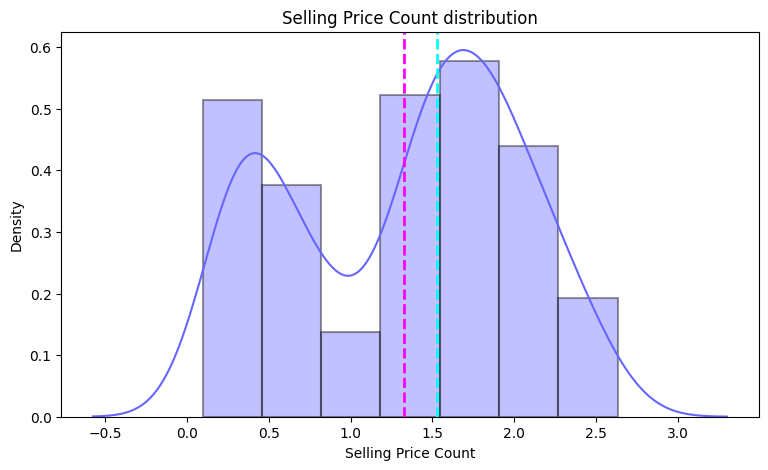

In [39]:
# Visualizing the distribution of dependent variable after log transformation
plt.figure(figsize=(9,5))
sns.distplot(np.log1p(df[dependent_variable]),color="#6666ff",hist_kws={'edgecolor':'black','linewidth':1.5})
plt.xlabel('Selling Price Count')
plt.title('Selling Price Count distribution')
plt.axvline(np.log1p(df['Selling_Price(lacs)']).mean(), color='magenta', linestyle='dashed', linewidth=2)
plt.axvline(np.log1p(df['Selling_Price(lacs)']).median(), color='cyan', linestyle='dashed', linewidth=2)
plt.show()

In [40]:
# Skew of the dependent variable after log transformation
np.log1p(df[dependent_variable]).skew()

Selling_Price(lacs)   -0.222356
dtype: float64

 ### 5. Data Scaling

In [41]:
features = [i for i in df.columns if i not in ['Selling_Price(lacs)']]
features

['Present_Price(lacs)',
 'Kms_Driven',
 'Past_Owners',
 'age',
 'Fuel_Type_Diesel',
 'Fuel_Type_Petrol',
 'Seller_Type_Individual',
 'Transmission_Manual']

In [42]:
# Scaling your data
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

 ### 6. Data(Train-Test) Splitting

In [43]:
# Defining dependent and independent variables
X = df.drop('Selling_Price(lacs)',axis=1)
y = np.log1p(df[dependent_variable])

In [44]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [45]:
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (210, 8)
x test:  (91, 8)
y train:  (210, 1)
y test:  (91, 1)


 # 6. ML Model Implementation

In [46]:
# Defining a function to print evaluation matrix
def evaluate_model(model, y_test, y_pred):

  '''takes model, y test and y pred values to print evaluation metrics, plot the actual and predicted values,
  plot the top 5 important features, and returns a list of the model scores'''

  # Apply inverse log transformation to y_test and y_pred as we have used log transformation
  y_t = np.exp(y_test)
  y_p = np.exp(y_pred)
  y_train2 = np.exp(y_train)
  y_train_pred = np.exp(model.predict(X_train))

  # Calculating Evaluation Matrix
  mse = mean_squared_error(y_t,y_p)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_t,y_p)
  r2_train = r2_score(y_train2, y_train_pred)
  r2 = r2_score(y_t,y_p)
  r2_adjusted = 1-(1-r2)*((len(X_test)-1)/(len(X_test)-X_test.shape[1]-1))

  # Printing Evaluation Matrix
  print("MSE :" , mse)
  print("RMSE :" ,rmse)
  print("MAE :" ,mae)
  print("Train R2 :" ,r2_train)
  print("Test R2 :" ,r2)
  print("Adjusted R2 : ", r2_adjusted)


  # plot actual and predicted values
  plt.figure(figsize=(12,4))
  plt.plot((y_p)[:100])
  plt.plot((np.array(y_t)[:100]))
  plt.legend(["Predicted","Actual"])
  plt.title('Actual and Predicted Selling Price', fontsize=12)

  try:
    importance = model.feature_importances_
  except:
    importance = model.coef_
  importance = np.absolute(importance)
  if len(importance)==len(features):
    pass
  else:
    importance = importance[0]

  # Feature importances
  feat = pd.Series(importance, index=features)
  plt.figure(figsize=(7,4))
  plt.title('Feature Importances (top 5) for '+str(model), fontsize = 12)
  plt.xlabel('Relative Importance')
  feat.nlargest(5).plot(kind='barh')


  model_score = [mse,rmse,mae,r2_train,r2,r2_adjusted]
  return model_score

In [47]:
# Create a score dataframe
score = pd.DataFrame(index = ['MSE', 'RMSE', 'MAE', 'Train R2', 'Test R2', 'Adjusted R2'])

## ML Model-1: Linear Regression

In [48]:
# Import the LinearRegression class
reg = LinearRegression()

# Fit the linear regression model to the training data
reg.fit(X_train, y_train)

# Predict on the model
y_pred_li = reg.predict(X_test)

### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart

MSE : 4.166906523706895
RMSE : 2.041300204209781
MAE : 1.2875415538806316
Train R2 : 0.6424690717013527
Test R2 : 0.49280916912387485
Adjusted R2 :  0.4433271368432772


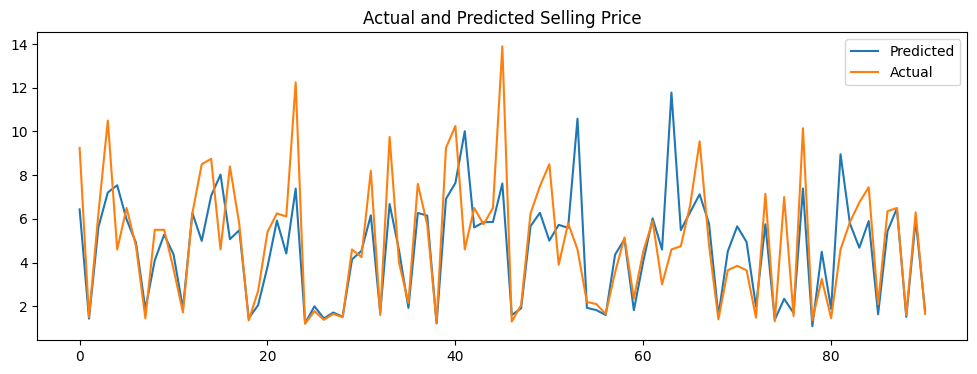

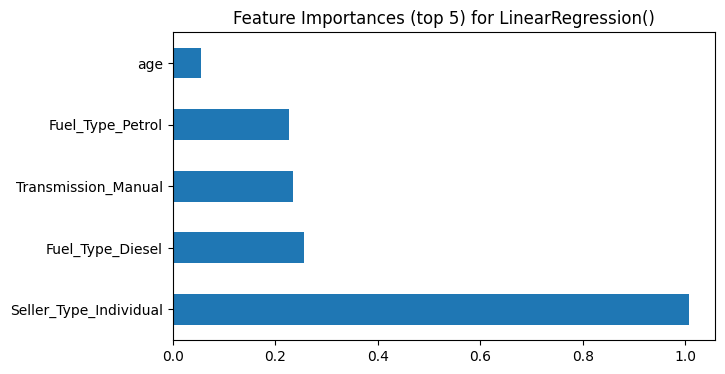

In [49]:
# Visualizing evaluation Metric Score chart
linear_score = evaluate_model(reg, y_test,y_pred_li)
score['Linear regression'] = linear_score

In [50]:
# Updated Evaluation Metric Score chart
score

,Linear regression
MSE,4.166907
RMSE,2.041300
MAE,1.287542
Train R2,0.642469
Test R2,0.492809
Adjusted R2,0.443327


In [51]:
# Convert y_test and y_pred to 1D
y_test = y_test.values.ravel() if hasattr(y_test, 'values') else y_test.ravel()
y_pred_li = y_pred_li.ravel()
# print(y_test.shape)
# print(y_pred_li.shape)
# Now create DataFrame


In [52]:
pred_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred_li,
    'Difference': y_test - y_pred_li
})

print(pred_df.head)

<bound method NDFrame.head of     Actual Value  Predicted Value  Difference
0       2.224624         1.861839    0.362784
1       0.405465         0.360547    0.044918
2       1.832581         1.726113    0.106469
3       2.351375         1.975248    0.376127
4       1.526056         2.019887   -0.493830
..           ...              ...         ...
86      1.848455         1.693195    0.155260
87      1.871802         1.868308    0.003494
88      0.470004         0.416642    0.053362
89      1.840550         1.785049    0.055501
90      0.500775         0.579171   -0.078396

[91 rows x 3 columns]>


In [53]:
# Define the model
reg = LinearRegression()

# Define the parameters to be optimized
param_grid = {'fit_intercept': [True, False]}

# Perform grid search
grid_search = GridSearchCV(reg, param_grid, cv=5, scoring='r2', return_train_score=True)
grid_search.fit(X_train, y_train)

# Print the best parameters and the corresponding score
print("Best parameters: ", grid_search.best_params_)
print("Best R2 score: ", grid_search.best_score_)

Best parameters:  {'fit_intercept': True}
Best R2 score:  0.8061662211239762


In [54]:
# Use the best parameter to train the model
best_reg = grid_search.best_estimator_
best_reg.fit(X_train, y_train)

# Predict on test data
y_pred_li2 = best_reg.predict(X_test)

MSE : 4.166906523706895
RMSE : 2.041300204209781
MAE : 1.2875415538806316
Train R2 : 0.6424690717013527
Test R2 : 0.49280916912387485
Adjusted R2 :  0.4433271368432772


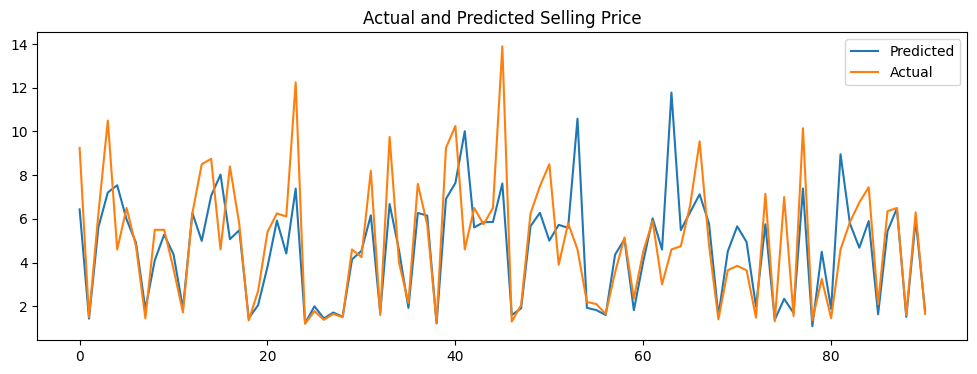

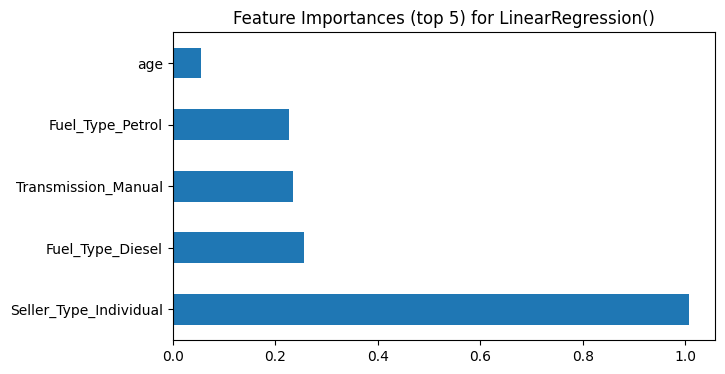

In [55]:
# Visualizing evaluation Metric Score chart
linear_score2 = evaluate_model(best_reg, y_test,y_pred_li2)

In [56]:
# Updated Evaluation Metric Score chart
score['Linear regression tuned'] = linear_score2
score

,Linear regression,Linear regression tuned
MSE,4.166907,4.166907
RMSE,2.041300,2.041300
MAE,1.287542,1.287542
Train R2,0.642469,0.642469
Test R2,0.492809,0.492809
Adjusted R2,0.443327,0.443327


## ML Model - 2 : Random Forest

In [57]:
# Import Random Forest Regressor class
rf = RandomForestRegressor(random_state=0)

# Fit the Random Forest model to your training data
rf.fit(X_train,y_train)

# Predict on the model
y_pred_rf1 = rf.predict(X_test)

### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

MSE : 0.5867222969426884
RMSE : 0.7659780002994135
MAE : 0.4984382904003695
Train R2 : 0.9851425465907697
Test R2 : 0.9285848704340067
Adjusted R2 :  0.9216175407202513


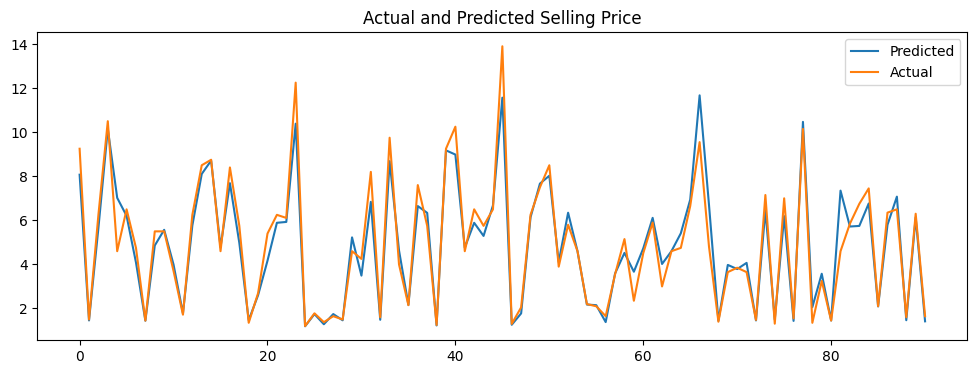

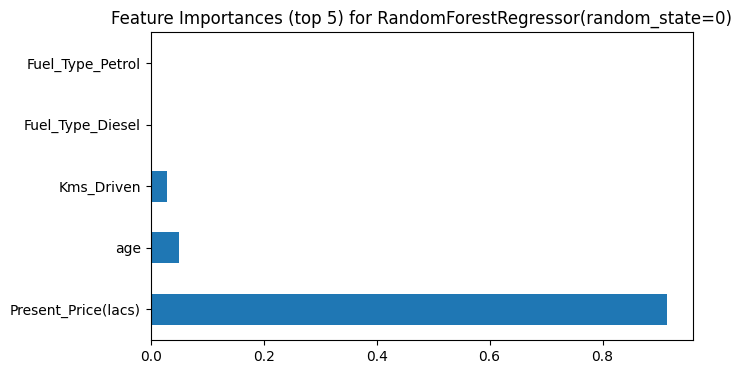

In [58]:
# Visualizing evaluation Metric Score chart
result = evaluate_model(rf, y_test,y_pred_rf1)
score['Random forest'] = result

In [59]:
# Updated Evaluation Metric Score chart
score

,Linear regression,Linear regression tuned,Random forest
MSE,4.166907,4.166907,0.586722
RMSE,2.041300,2.041300,0.765978
MAE,1.287542,1.287542,0.498438
Train R2,0.642469,0.642469,0.985143
Test R2,0.492809,0.492809,0.928585
Adjusted R2,0.443327,0.443327,0.921618


### 2. Cross- Validation & Hyperparameter Tuning

In [60]:
# Random forest model
rf_model = RandomForestRegressor(random_state=0)
rf_params = {'n_estimators':[300],                    
             'min_samples_leaf':np.arange(20,25)}     

In [61]:
# Fitting a Random Forest model with best parameters obtained from gridsearch
rf_gridsearch = GridSearchCV(rf_model,rf_params,cv=6,scoring='neg_root_mean_squared_error')
rf_gridsearch.fit(X_train,y_train)
rf_best_params = rf_gridsearch.best_params_

In [62]:
# Best parameters for random forests
rf_best_params

{'min_samples_leaf': np.int64(20), 'n_estimators': 300}

In [63]:
# Building Random Forest model with best parameters
rf_model = RandomForestRegressor(n_estimators=rf_best_params['n_estimators'],
                                 min_samples_leaf=rf_best_params['min_samples_leaf'],
                                 random_state=0)

In [64]:
# Fitting model
rf_model.fit(X_train,y_train)

# Predict on the model
y_pred_rf = rf_model.predict(X_test)

MSE : 2.1582146957363166
RMSE : 1.4690863472704103
MAE : 1.0099135899893898
Train R2 : 0.7708414296394233
Test R2 : 0.7373047130978638
Adjusted R2 :  0.7116759046196066


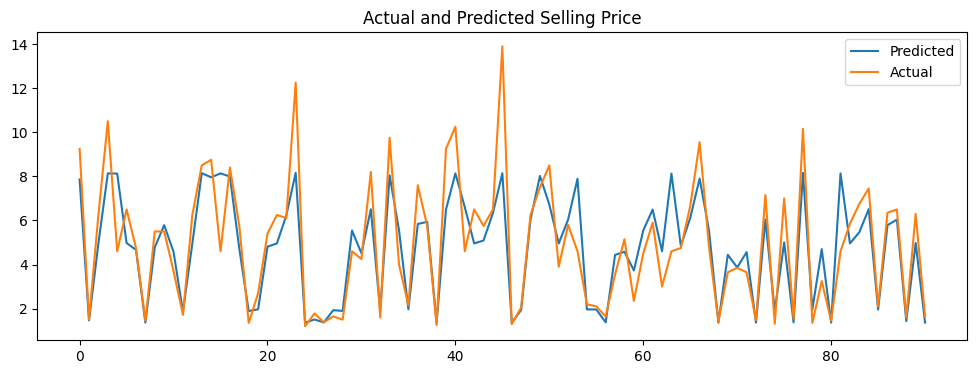

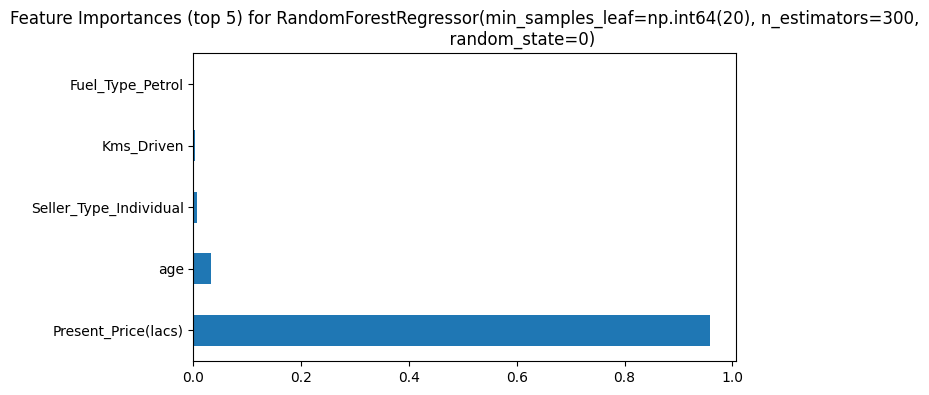

In [65]:
# Evaluation matrices for RandomForest
result = evaluate_model(rf_model, y_test,y_pred_rf)
score['Random forest tuned'] = result

In [66]:
# Updated Evaluation Metric Score chart
score

,Linear regression,Linear regression tuned,Random forest,Random forest tuned
MSE,4.166907,4.166907,0.586722,2.158215
RMSE,2.041300,2.041300,0.765978,1.469086
MAE,1.287542,1.287542,0.498438,1.009914
Train R2,0.642469,0.642469,0.985143,0.770841
Test R2,0.492809,0.492809,0.928585,0.737305
Adjusted R2,0.443327,0.443327,0.921618,0.711676


### Plot R2 scores for each model

In [67]:
print(score.columns)

Index(['Linear regression', 'Linear regression tuned', 'Random forest',
       'Random forest tuned'],
      dtype='object')


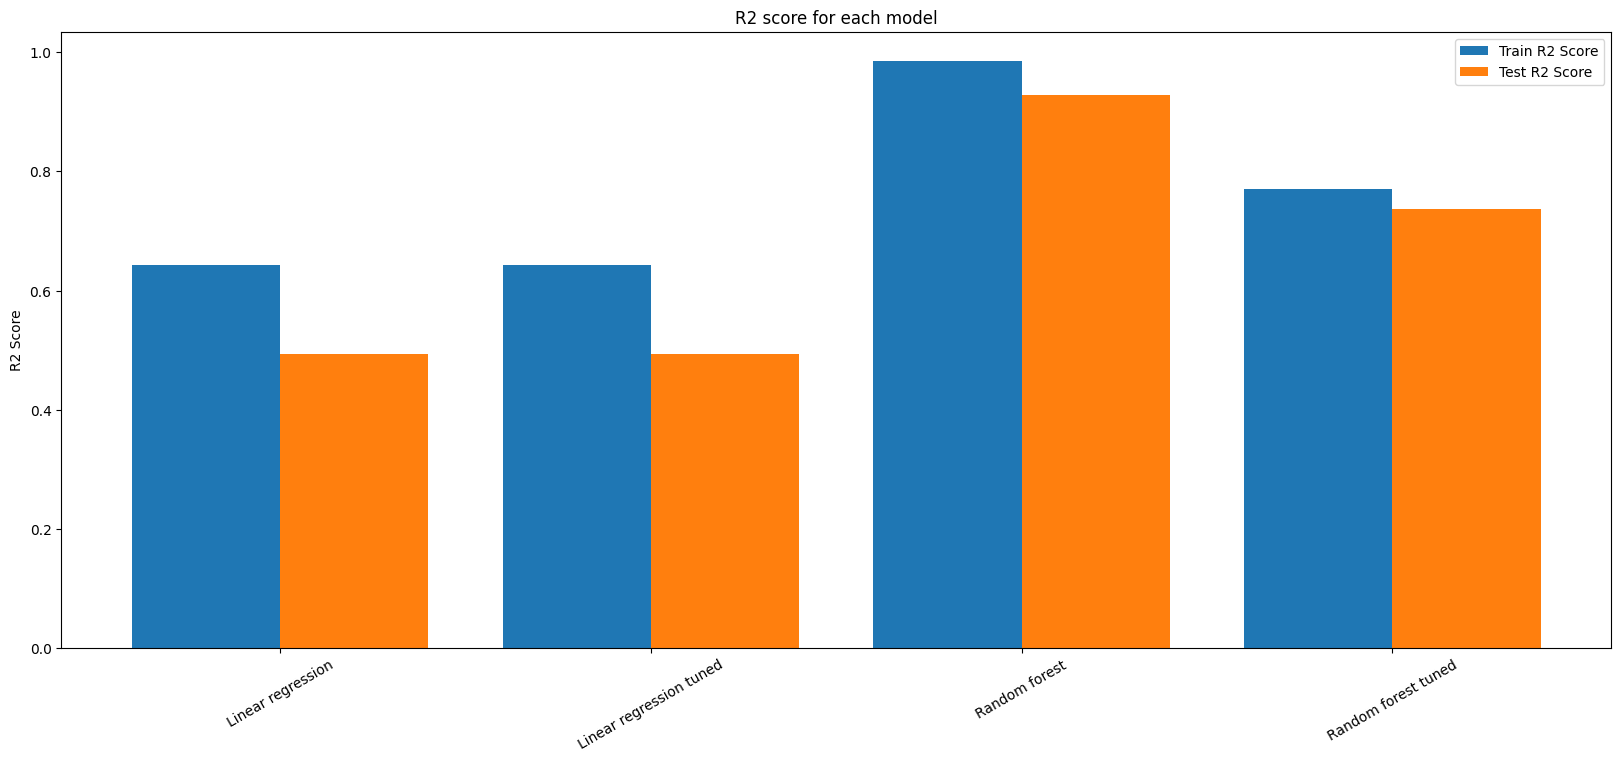

In [68]:
# R2 Scores plot

models = list(score.columns)
train = score.iloc[-3,:]
test = score.iloc[-2,:]

X_axis = np.arange(len(models))

plt.figure(figsize=(20,8))
plt.bar(X_axis - 0.2, train, 0.4, label = 'Train R2 Score')
plt.bar(X_axis + 0.2, test, 0.4, label = 'Test R2 Score')


plt.xticks(X_axis,models, rotation=30)
plt.ylabel("R2 Score")
plt.title("R2 score for each model")
plt.legend()
plt.show()

# ***7.*** ***Future Work***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [69]:
# Save the model to a pickle file
with open("random_forest_regression_model.pkl", "wb") as f:
  pickle.dump(rf, f)

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [70]:
# Load the model from the pickle file
with open("random_forest_regression_model.pkl", "rb") as f:
    loaded_rf_model = pickle.load(f)

new_test_preds = loaded_rf_model.predict(X_test)

# Sanity Check
mse = mean_squared_error(y_test, new_test_preds)
mae = mean_absolute_error(y_test, new_test_preds)
r2 = r2_score(y_test, new_test_preds)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 0.01913236988739946
MAE: 0.09641740511816019
R2 Score: 0.9577440967815708


# **Conclusion**

This project explores the automotive industry's intricate dynamics, aiming to predict car prices with machine learning. By analyzing various factors such as fuel type, seller type, and transmission, we uncover valuable insights and select a robust model for accurate price prediction.

**Key Insights:**

- The 'city' model is the top-selling car, followed by 'corolla altis,' 'verna,' 'fortuner,' and 'brio,' providing a snapshot of popular car models in the market.

- The year 2015 saw the highest number of car purchases, making it the most favored year for buying cars, followed by 2016 and 2014.

- 'Petrol' is the predominant fuel type for cars in the dataset, surpassing 'Diesel' and 'CNG,' indicating fuel preference among buyers.

- The majority of cars are sold through dealers, underscoring the role of dealerships in the automotive market.

- 'Manual' transmission cars significantly outnumber 'Automatic' transmission cars, showcasing consumer transmission preferences.

- 'First Owner' cars generally command higher 'Selling_Price,' while 'Second' or 'Third Owner' cars often have lower prices.

- 'Dealer' sellers usually ask for higher prices than 'Individual' sellers, revealing the impact of seller type on prices.

- 'Automatic' transmission cars typically have higher prices than their 'Manual' counterparts, reflecting consumer preferences.


- Various machine learning models were assessed, with the Random Forest model being chosen for car price prediction due to its robust performance.

-  The Random Forest model achieved impressive accuracy with 98% training accuracy and 92% testing accuracy, making it a suitable choice for car price prediction.


